### 1. Importing Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')

### 2. Data Loading

In [2]:
fear = pd.read_csv('PrimeTrade AI/fear_greed_index.csv')

fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
hist = pd.read_csv('PrimeTrade AI/historical_data.csv')

hist.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
68492,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,19.373,59.42,1151.14,BUY,25-02-2025 07:23,235745.26000,Open Long,0.000000,0xd5d0df14e8a13d5a36a2041e692a2a0201c000a95d35...,74607648920,False,0.055254,3.640000e+14,1.740000e+12
51256,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,15.575,36.81,573.32,BUY,07-03-2025 00:00,4947.86000,Open Long,0.000000,0x10a4cf0273b5e00e29c9041f08e73f01d600e640f810...,77726746772,True,0.200660,5.660000e+14,1.740000e+12
157164,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,14.330,15.98,228.99,SELL,11-12-2024 16:56,41778.98423,Sell,12.790389,0x42184fb11f6abc77c6170418f7007e02010900970778...,54505446110,False,0.000000,3.580000e+14,1.730000e+12
127386,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,SOL,136.880,9.13,1249.71,BUY,04-03-2025 10:50,13.78000,Open Long,0.000000,0x8d5b5491292c36f6a3a2041edf677b02037000712b9c...,76932425023,True,0.419904,1.070000e+15,1.740000e+12
104050,0x8477e447846c758f5a675856001ea72298fd9cb5,APE,1.419,356.00,505.16,SELL,20-10-2024 17:58,-6683.60000,Open Short,0.000000,0x6474ea49ba856d1a8eb20414bd96b6017600ee2b6544...,42628598262,True,0.176807,4.100000e+14,1.730000e+12


In [4]:
fear.shape, hist.shape

((2644, 4), (211224, 16))

In [5]:
fear.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [6]:
hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [7]:
fear.isnull().sum().sum(), hist.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [8]:
fear["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [9]:
fear.duplicated().sum(), hist.duplicated().sum()

(np.int64(0), np.int64(0))

In [10]:
hist['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

### 3. Data Cleaning and Preprocessing

In [11]:
hist["datetime_ist"] = pd.to_datetime(
    hist["Timestamp IST"], format="%d-%m-%Y %H:%M"
)
hist["date"] = hist["datetime_ist"].dt.date.astype(str)

In [12]:
hist[["Timestamp IST", "datetime_ist", "date"]].head()

,Timestamp IST,datetime_ist,date
0,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
1,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
2,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
3,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
4,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02


In [13]:
"date range : " + hist["date"].min() + " & " + hist["date"].max()

'date range : 2023-05-01 & 2025-05-01'

In [14]:
fear_slim = fear[["date", "value", "classification"]].rename(
    columns={
        "value"          : "fg_value",
        "classification" : "fg_label"
    }
)

In [15]:
hist_merged = hist.merge(fear_slim, on="date",how="left")

In [16]:
hist_merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime_ist,date,fg_value,fg_label
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed


In [17]:
n_matched   = hist_merged["fg_label"].notna().sum()
n_unmatched = hist_merged["fg_label"].isna().sum()

In [18]:
n_matched, n_unmatched

(np.int64(211218), np.int64(6))

In [19]:
hist_merged['fg_label'].value_counts(dropna=False)

fg_label
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

### 5. Feature Engineering

In [20]:
def win_rate(pnl_series: pd.Series) -> float:
    closing = pnl_series[pnl_series != 0]
    if len(closing) == 0:
        return np.nan
    return (closing > 0).sum() / len(closing)

def long_short_ratio(direction_series: pd.Series) -> float:
    longs  = direction_series.str.contains("Long",  case=False).sum()
    shorts = direction_series.str.contains("Short", case=False).sum()
    return longs / shorts if shorts > 0 else np.nan

In [21]:
group_cols = ["Account", "date", "fg_label", "fg_value"]
 
daily_metrics = (
    hist_merged
    .groupby(["Account", "date", "fg_label", "fg_value"], dropna=False)
    .agg(
        # --- PnL ---
        total_pnl        = ("Closed PnL",  "sum"),
        # --- Volume / sizing ---
        avg_size_usd     = ("Size USD",    "mean"),
        total_volume_usd = ("Size USD",    "sum"),
        # --- Activity ---
        trade_count      = ("Trade ID",    "count"),
        # --- Fees ---
        total_fee        = ("Fee",         "sum"),
        # --- Win rate helper cols stored for inspection ---
        _pnl_list        = ("Closed PnL",  list),
        _dir_list        = ("Direction",   list),
    )
    .reset_index()
)

In [22]:
daily_metrics["win_rate"] = daily_metrics["_pnl_list"].apply(
    lambda x: win_rate(pd.Series(x))
)
daily_metrics["long_short_ratio"] = daily_metrics["_dir_list"].apply(
    lambda x: long_short_ratio(pd.Series(x))
)

In [23]:
hist_merged["leverage_proxy"] = hist_merged.apply(
    lambda r: r["Size USD"] / r["Start Position"]
    if r["Start Position"] > 0 else np.nan,
    axis=1
)
 
leverage_daily = (
    hist_merged
    .groupby(["Account", "date"], dropna=False)["leverage_proxy"]
    .mean()
    .reset_index()
    .rename(columns={"leverage_proxy": "avg_leverage_proxy"})
)

In [24]:
daily_metrics = daily_metrics.merge(leverage_daily, on=["Account", "date"], how="left")

In [25]:
daily_metrics.drop(columns=["_pnl_list", "_dir_list"], inplace=True)

In [26]:
# ── Net PnL after fees ───────────────────────
daily_metrics["net_pnl"] = daily_metrics["total_pnl"] - daily_metrics["total_fee"]

In [27]:
# ── Final column ordering ────────────────────
final_cols = [
    "Account", "date", "fg_label", "fg_value",
    "trade_count",
    "total_pnl", "total_fee", "net_pnl",
    "win_rate",
    "avg_size_usd", "total_volume_usd",
    "avg_leverage_proxy",
    "long_short_ratio",
]
daily_metrics = daily_metrics[final_cols]

In [28]:
print("\n" + "=" * 55)
print("DAILY METRICS TABLE — OVERVIEW")
print("=" * 55)
print(f"Shape                : {daily_metrics.shape}")
print(f"Unique traders       : {daily_metrics['Account'].nunique():,}")
print(f"Date range           : {daily_metrics['date'].min()}  →  {daily_metrics['date'].max()}")
print(f"\nSample (5 rows):\n{daily_metrics.head(5).to_string(index=False)}")
print(f"\nDescriptive stats:\n{daily_metrics.describe().round(4).to_string()}")


DAILY METRICS TABLE — OVERVIEW
Shape                : (2341, 13)
Unique traders       : 32
Date range           : 2023-05-01  →  2025-05-01

Sample (5 rows):
                                   Account       date      fg_label  fg_value  trade_count  total_pnl  total_fee       net_pnl  win_rate  avg_size_usd  total_volume_usd  avg_leverage_proxy  long_short_ratio
0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11 Extreme Greed      76.0          177        0.0 167.796055   -167.796055       NaN   5089.718249         900880.13                 NaN               0.0
0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17 Extreme Greed      90.0           68        0.0  67.883615    -67.883615       NaN   7976.664412         542413.18                 NaN               0.0
0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18 Extreme Greed      83.0           40        0.0  94.937983    -94.937983       NaN  23734.500000         949380.00                 NaN               0.0
0x083384f897e

In [29]:
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 130,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor'  : '#1a1a1a',
    'axes.edgecolor'  : '#333333',
    'axes.labelcolor' : '#cccccc',
    'xtick.color'     : '#aaaaaa',
    'ytick.color'     : '#aaaaaa',
    'text.color'      : '#eeeeee',
    'grid.color'      : '#2a2a2a',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444444',
    'font.size'       : 11,
})

# Sentiment-aware color palette (red = fear, green = greed)
SENTIMENT_COLORS = {
    'Extreme Fear' : '#e74c3c',
    'Fear'         : '#e67e22',
    'Neutral'      : '#95a5a6',
    'Greed'        : '#27ae60',
    'Extreme Greed': '#2ecc71',
}

# Ordered categories for consistent axis ordering
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

In [30]:
daily_metrics["date"] = pd.to_datetime(daily_metrics["date"])
hist_merged["date"] = pd.to_datetime(hist_merged["date"])

In [31]:
daily = daily_metrics.dropna(subset=['fg_label']).copy()
hist = hist_merged.dropna(subset=['fg_label']).copy()

In [32]:
daily['fg_label'] = pd.Categorical(
    daily['fg_label'], categories=SENTIMENT_ORDER, ordered=True
)
hist['fg_label'] = pd.Categorical(
    hist['fg_label'], categories=SENTIMENT_ORDER, ordered=True
)

In [33]:
print(f"daily shape : {daily.shape}")
print(f"hist shape : {hist.shape}")
print(f"\nSentiment distribution (trader-days):")
print(daily['fg_label'].value_counts().sort_index())

daily shape : (2340, 13)
hist shape : (211218, 21)

Sentiment distribution (trader-days):
fg_label
Extreme Fear     160
Fear             630
Neutral          376
Greed            648
Extreme Greed    526
Name: count, dtype: int64


In [34]:
daily.sample(3)

,Account,date,fg_label,fg_value,trade_count,total_pnl,total_fee,net_pnl,win_rate,avg_size_usd,total_volume_usd,avg_leverage_proxy,long_short_ratio
1733,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,2025-02-26,Extreme Fear,21.0,20,0.000000,1.999079,-1.999079,NaN,749.825500,14996.51,2.601946,NaN
2030,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2025-02-03,Fear,44.0,258,46742.288748,153.000273,46589.288475,1.0,1333.055698,343928.37,0.319415,0.00
778,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2024-07-22,Greed,70.0,21,2273.293010,78.857900,2194.435110,1.0,10728.970000,225308.37,6962.740497,1.75


In [35]:
hist.sample(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime_ist,date,fg_value,fg_label,leverage_proxy
65541,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,22.111,0.66,14.59,SELL,24-02-2025 19:02,19936.65,Close Long,0.142956,...,74429385597,False,0.001400,5.910000e+14,1.740000e+12,2025-02-24 19:02:00,2025-02-24,49.0,Neutral,0.000732
63251,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,21.529,10.00,215.29,BUY,24-02-2025 13:14,87225.68,Open Long,0.000000,...,74400900676,False,0.020667,8.140000e+14,1.740000e+12,2025-02-24 13:14:00,2025-02-24,49.0,Neutral,0.002468
65657,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,22.113,10.00,221.13,SELL,24-02-2025 19:02,16864.86,Close Long,2.186000,...,74429385595,False,0.021228,1.080000e+15,1.740000e+12,2025-02-24 19:02:00,2025-02-24,49.0,Neutral,0.013112


In [36]:
fg_performance = (
    daily
    .groupby("fg_label")
    .agg(
        avg_pnl        = ("total_pnl",  "mean"),
        median_pnl     = ("total_pnl",  "median"),
        avg_net_pnl    = ("net_pnl",    "mean"),
        avg_win_rate   = ("win_rate",   "mean"),
        avg_vol_usd    = ("avg_size_usd","mean"),
        median_vol_usd = ("avg_size_usd","median"),
        avg_total_volume = ("total_volume_usd", "mean"),
        median_trade_count  = ("trade_count","median"),
        total_trade_count  = ("trade_count","sum"),
        median_leverage   = ("avg_leverage_proxy", "median"),
        total_days     = ("date",       "nunique"),
        sample_size    = ("total_pnl",  "count"),
    )
    .reset_index()
)

In [37]:
fg_performance

,fg_label,avg_pnl,median_pnl,avg_net_pnl,avg_win_rate,avg_vol_usd,median_vol_usd,avg_total_volume,median_trade_count,total_trade_count,median_leverage,total_days,sample_size
0,Extreme Fear,4619.439053,218.377399,4470.135091,0.771535,6773.464125,2315.629870,715526.634000,50.5,21400,54.652282,14,160
1,Fear,5328.818161,107.892532,5182.061100,0.862488,8975.928546,1752.677497,767182.206016,26.0,61837,124.727893,91,630
2,Neutral,3438.618818,167.551743,3333.900019,0.835721,6963.694861,1704.405417,479367.189043,29.5,37686,76.357705,67,376
3,Greed,3318.100730,158.214922,3220.726205,0.846074,6427.866594,2052.534828,445343.356049,25.0,50303,116.461828,193,648
4,Extreme Greed,5161.922644,418.319862,5110.533546,0.867883,5371.637182,2003.480176,236625.788156,31.5,39992,5.645027,114,526


In [38]:
fg_performance["median_pnl"].round(2)

0    218.38
1    107.89
2    167.55
3    158.21
4    418.32
Name: median_pnl, dtype: float64

### 6. EDA and Visulaizations

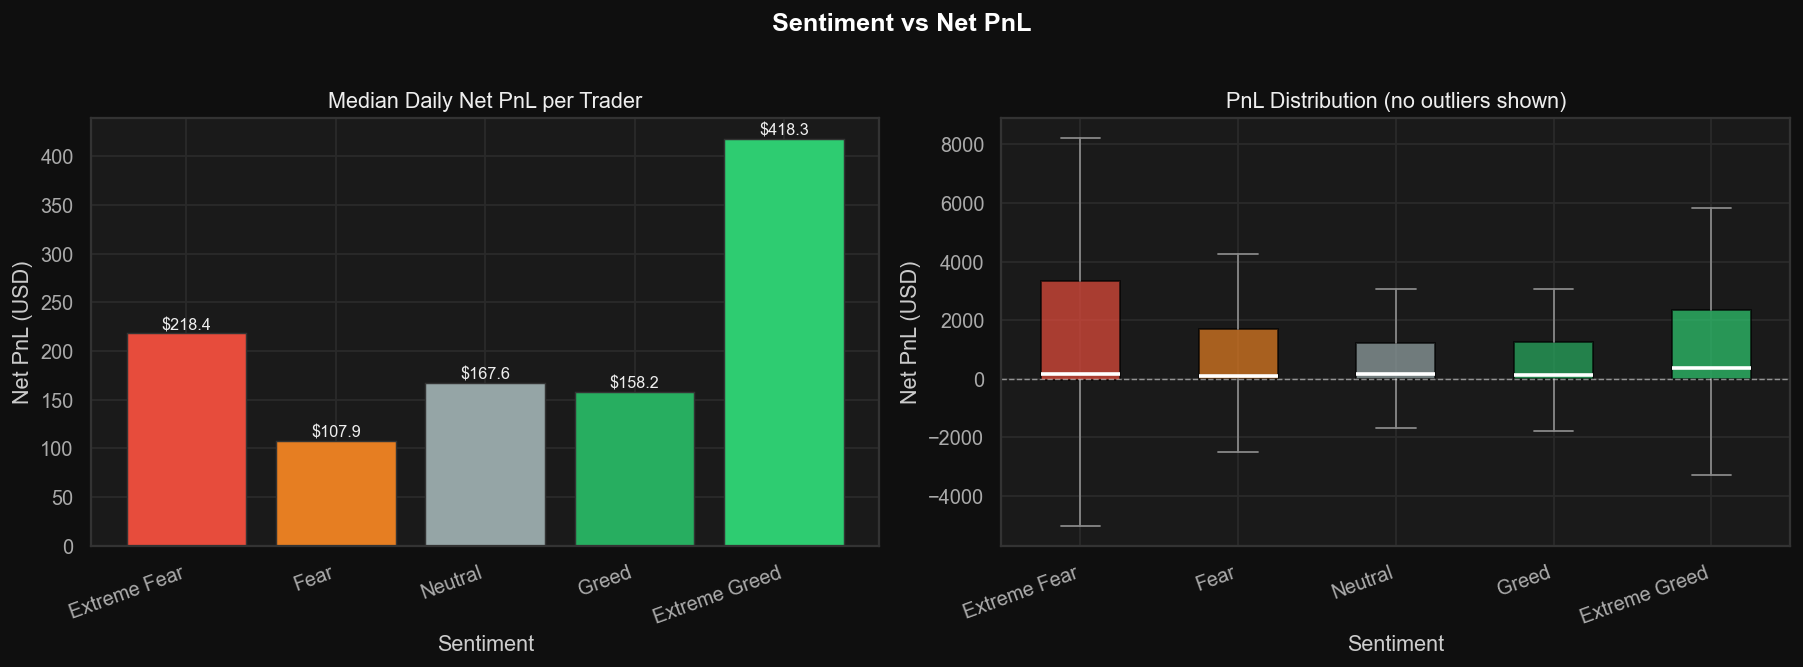

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment vs Net PnL', fontsize=14, fontweight='bold', color='white', y=1.02)

# ── Bar: Median PnL ──
ax = axes[0]
colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
bars = ax.bar(
    SENTIMENT_ORDER,
    fg_performance["median_pnl"],
    color=colors, edgecolor='#333', linewidth=0.8
)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Median Daily Net PnL per Trader', fontsize=12)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Net PnL (USD)')
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
for bar, val in zip(bars, fg_performance["median_pnl"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:.1f}', ha='center', va='bottom', fontsize=9)

# ── Box: PnL distribution ──
ax2 = axes[1]
groups = [daily[daily['fg_label'] == s]['net_pnl'].dropna().values
          for s in SENTIMENT_ORDER]
bp = ax2.boxplot(
    groups,
    labels=SENTIMENT_ORDER,
    patch_artist=True,
    showfliers=False,   # hide extreme outliers for readability
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#888'),
    capprops=dict(color='#888'),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_title('PnL Distribution (no outliers shown)', fontsize=12)
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Net PnL (USD)')
ax2.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

plt.tight_layout()
plt.show()

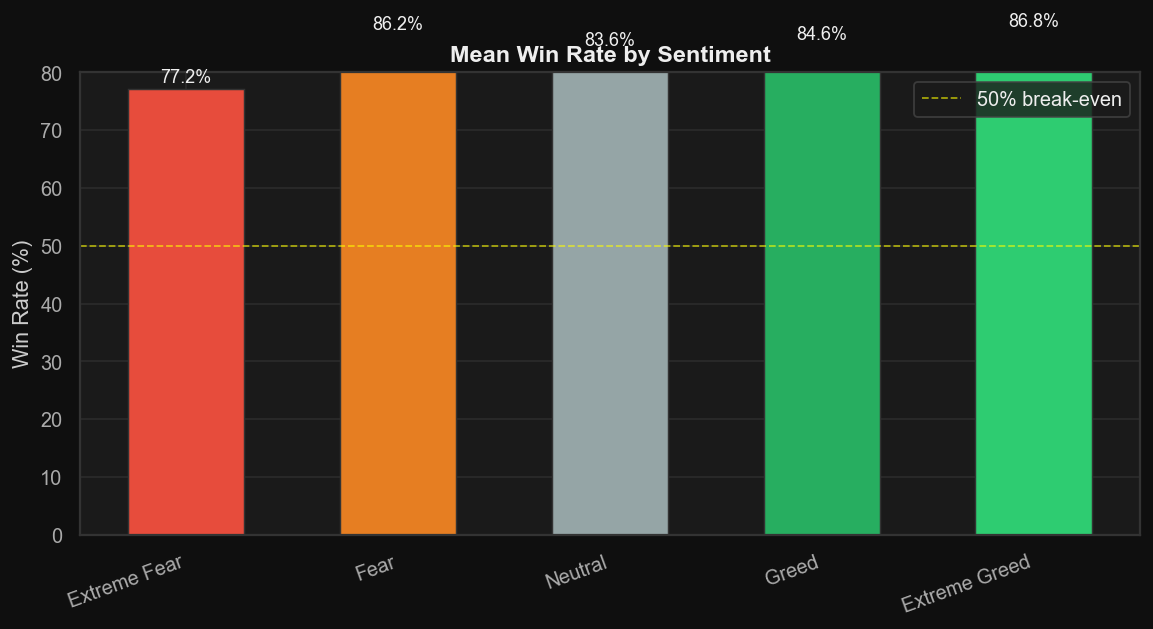

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

x = np.arange(len(SENTIMENT_ORDER))
bars = ax.bar(
    x,
    fg_performance["avg_win_rate"] * 100,
    color=colors, edgecolor='#333', linewidth=0.8, width=0.55
)
ax.axhline(50, color='yellow', linewidth=1, linestyle='--', alpha=0.6, label='50% break-even')
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax.set_title('Mean Win Rate by Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 80)
ax.legend()
for bar, val in zip(bars, fg_performance["avg_win_rate"] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Drawdown Proxy by Sentiment:
               avg_loss  median_loss  worst_loss  losing_days  loss_day_pct
fg_label                                                                   
Extreme Fear   -7268.87      -126.05   -77527.41           67         41.88
Fear           -1703.39       -25.66  -108920.04          237         37.62
Neutral        -2230.30       -13.22  -114278.29          134         35.64
Greed          -3509.84       -11.50  -359574.55          251         38.73
Extreme Greed  -1436.63        -7.35  -132402.68          161         30.61


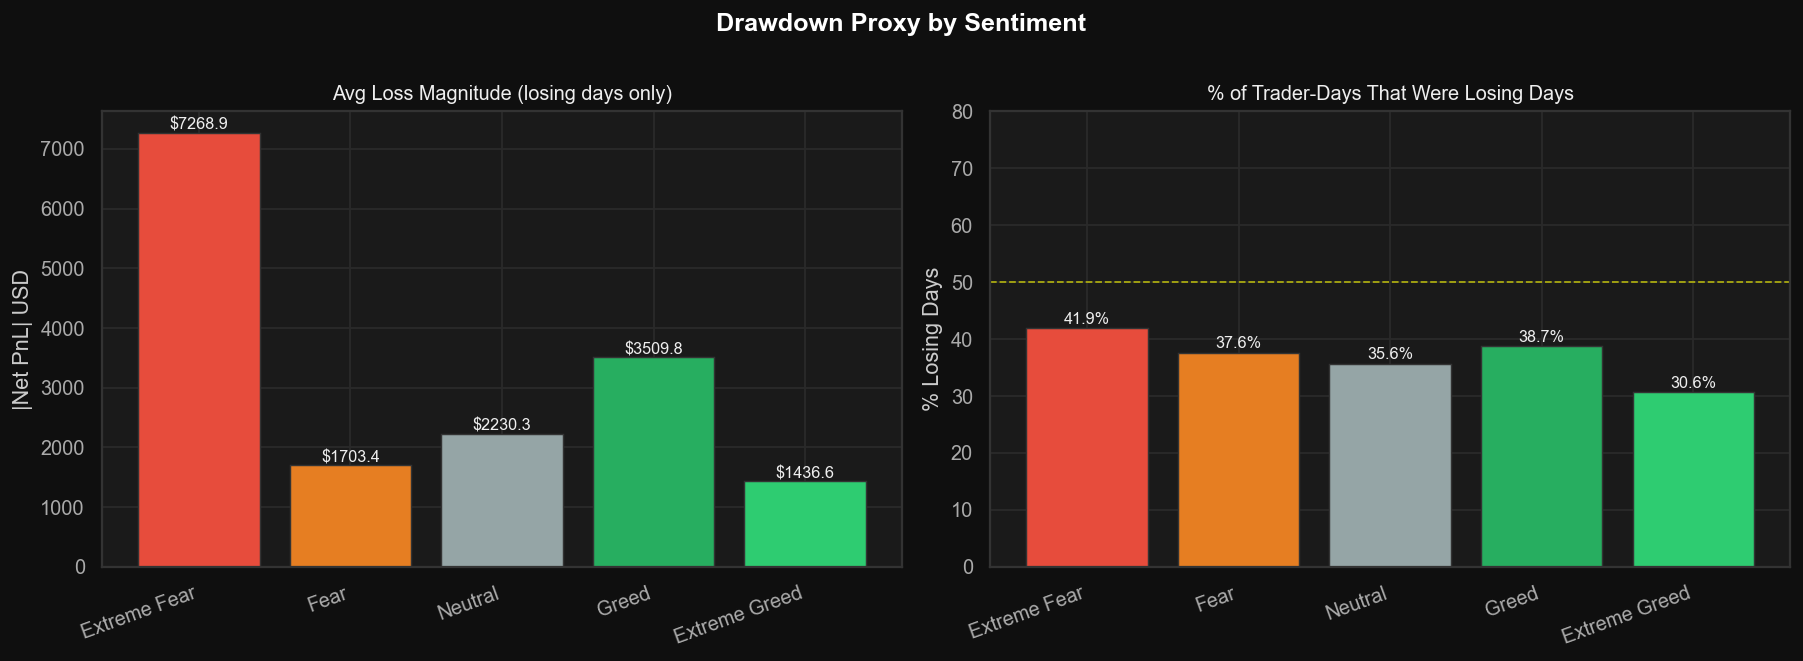

In [41]:
# Drawdown proxy: average of losing days only
losing_days = daily[daily['net_pnl'] < 0].copy()

drawdown_by_sentiment = (
    losing_days
    .groupby('fg_label', observed=True)['net_pnl']
    .agg(
        avg_loss   = 'mean',
        median_loss= 'median',
        worst_loss = 'min',
        losing_days= 'count'
    )
    .reindex(SENTIMENT_ORDER)
)

# Proportion of losing days per sentiment
total_by_sentiment = daily.groupby('fg_label', observed=True).size().reindex(SENTIMENT_ORDER)
drawdown_by_sentiment['loss_day_pct'] = (
    drawdown_by_sentiment['losing_days'] / total_by_sentiment * 100
)
print("Drawdown Proxy by Sentiment:")
print(drawdown_by_sentiment.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Drawdown Proxy by Sentiment', fontsize=14, fontweight='bold',
             color='white', y=1.01)

# ── Average loss magnitude ──
ax = axes[0]
bars = ax.bar(
    SENTIMENT_ORDER,
    drawdown_by_sentiment['avg_loss'].abs(),
    color=colors, edgecolor='#333', linewidth=0.8
)
ax.set_title('Avg Loss Magnitude (losing days only)', fontsize=11)
ax.set_ylabel('|Net PnL| USD')
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
for bar, val in zip(bars, drawdown_by_sentiment['avg_loss'].abs()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}', ha='center', va='bottom', fontsize=9)

# ── % of days that were losing days ──
ax2 = axes[1]
bars2 = ax2.bar(
    SENTIMENT_ORDER,
    drawdown_by_sentiment['loss_day_pct'],
    color=colors, edgecolor='#333', linewidth=0.8
)
ax2.axhline(50, color='yellow', linewidth=1, linestyle='--', alpha=0.6)
ax2.set_title('% of Trader-Days That Were Losing Days', fontsize=11)
ax2.set_ylabel('% Losing Days')
ax2.set_ylim(0, 80)
ax2.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
for bar, val in zip(bars2, drawdown_by_sentiment['loss_day_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

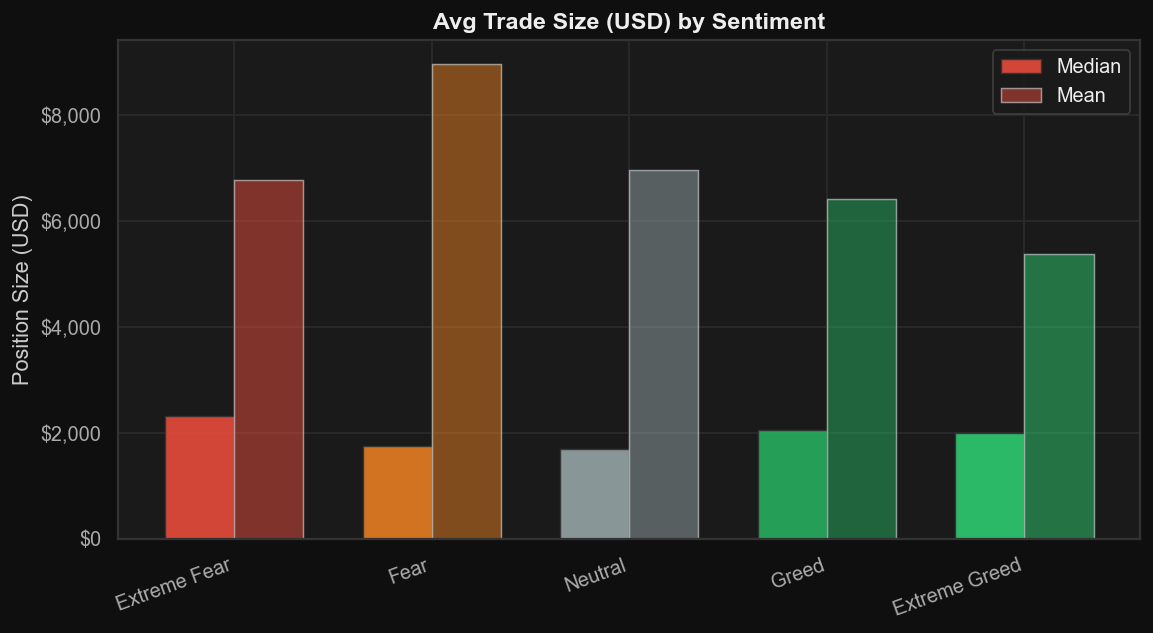

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

x = np.arange(len(SENTIMENT_ORDER))
w = 0.35
b1 = ax.bar(x - w/2, fg_performance["median_vol_usd"], width=w,
            color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
            edgecolor='#333', linewidth=0.8, label='Median', alpha=0.9)
b2 = ax.bar(x + w/2, fg_performance["avg_vol_usd"], width=w,
            color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
            edgecolor='white', linewidth=0.8, label='Mean', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax.set_title('Avg Trade Size (USD) by Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Position Size (USD)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

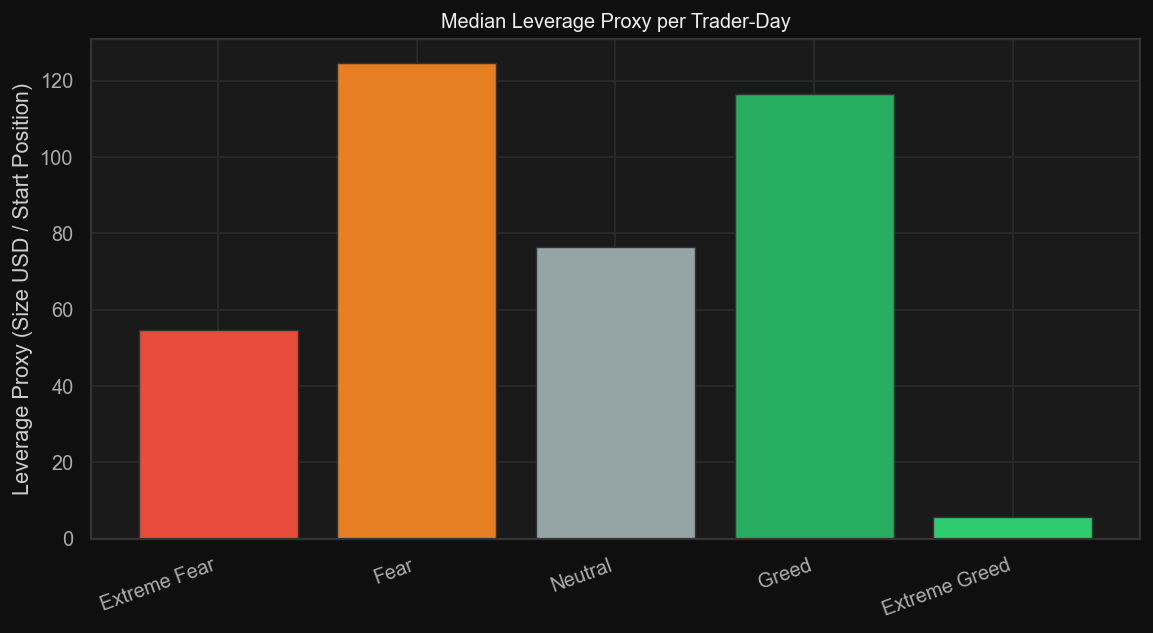

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

ax.bar(
    SENTIMENT_ORDER,
    fg_performance["median_leverage"],
    color=colors, edgecolor='#333', linewidth=0.8
)
ax.set_title('Median Leverage Proxy per Trader-Day', fontsize=11)
ax.set_ylabel('Leverage Proxy (Size USD / Start Position)')
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

plt.tight_layout()
plt.show()

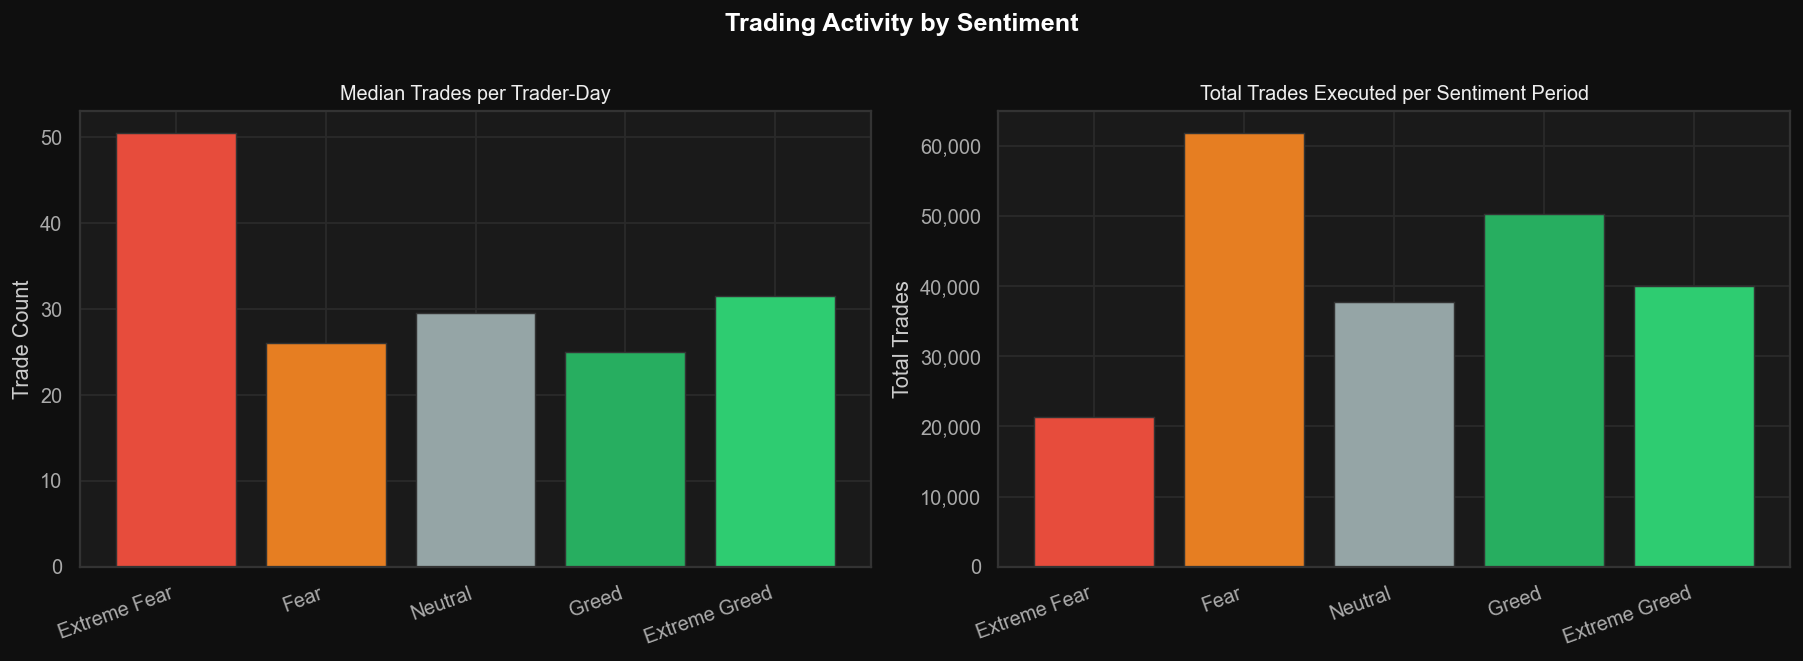

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trading Activity by Sentiment', fontsize=14, fontweight='bold',
             color='white', y=1.01)

# Median trades per trader-day
ax = axes[0]
ax.bar(SENTIMENT_ORDER, fg_performance["median_trade_count"],
       color=colors, edgecolor='#333', linewidth=0.8)
ax.set_title('Median Trades per Trader-Day', fontsize=11)
ax.set_ylabel('Trade Count')
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

# Total trade volume by sentiment (shows data distribution)
ax2 = axes[1]
ax2.bar(SENTIMENT_ORDER, fg_performance["total_trade_count"],
        color=colors, edgecolor='#333', linewidth=0.8)
ax2.set_title('Total Trades Executed per Sentiment Period', fontsize=11)
ax2.set_ylabel('Total Trades')
ax2.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

Long/Short Distribution by Sentiment:
               longs  shorts  total  pct_long  pct_short  ls_ratio
fg_label                                                          
Extreme Fear   13257    6302  19559    67.780     32.220     2.104
Fear           35116   20140  55256    63.551     36.449     1.744
Neutral        20242   12230  32472    62.337     37.663     1.655
Greed          16581   23026  39607    41.864     58.136     0.720
Extreme Greed  13504   14178  27682    48.783     51.217     0.952


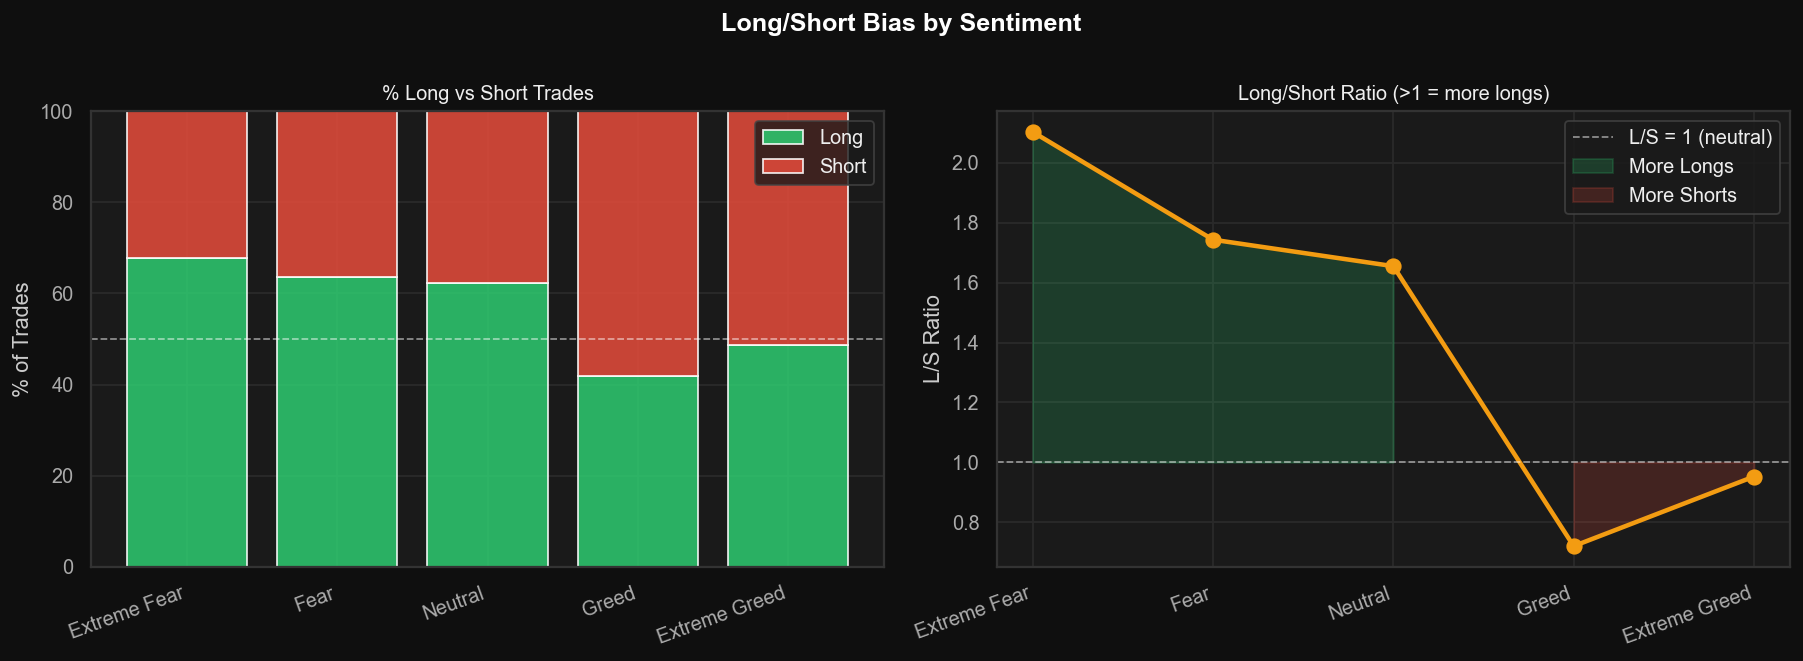

In [45]:
# Compute long/short ratio directly from the raw trade log for accuracy
hist["is_long"] = hist['Direction'].str.contains('Long',  case=False)
hist['is_short'] = hist['Direction'].str.contains('Short', case=False)

ls_by_sentiment = (
    hist
    .groupby('fg_label', observed=True)
    .agg(longs=('is_long', 'sum'), shorts=('is_short', 'sum'))
    .reindex(SENTIMENT_ORDER)
)
ls_by_sentiment['total']    = ls_by_sentiment['longs'] + ls_by_sentiment['shorts']
ls_by_sentiment['pct_long'] = ls_by_sentiment['longs']  / ls_by_sentiment['total'] * 100
ls_by_sentiment['pct_short']= ls_by_sentiment['shorts'] / ls_by_sentiment['total'] * 100
ls_by_sentiment['ls_ratio'] = ls_by_sentiment['longs']  / ls_by_sentiment['shorts']

print("Long/Short Distribution by Sentiment:")
print(ls_by_sentiment.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Long/Short Bias by Sentiment', fontsize=14, fontweight='bold',
             color='white', y=1.01)

# ── Stacked bar: % long vs short ──
ax = axes[0]
x = np.arange(len(SENTIMENT_ORDER))
ax.bar(x, ls_by_sentiment['pct_long'],  label='Long',  color='#2ecc71', alpha=0.85)
ax.bar(x, ls_by_sentiment['pct_short'], bottom=ls_by_sentiment['pct_long'],
       label='Short', color='#e74c3c', alpha=0.85)
ax.axhline(50, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax.set_title('% Long vs Short Trades', fontsize=11)
ax.set_ylabel('% of Trades')
ax.set_ylim(0, 100)
ax.legend()

# ── L/S ratio line ──
ax2 = axes[1]
ax2.plot(SENTIMENT_ORDER, ls_by_sentiment['ls_ratio'],
         marker='o', color='#f39c12', linewidth=2.5, markersize=8)
ax2.axhline(1.0, color='white', linewidth=1, linestyle='--', alpha=0.5,
            label='L/S = 1 (neutral)')
ax2.fill_between(SENTIMENT_ORDER, ls_by_sentiment['ls_ratio'], 1.0,
                  where=ls_by_sentiment['ls_ratio'] >= 1.0,
                  alpha=0.2, color='#2ecc71', label='More Longs')
ax2.fill_between(SENTIMENT_ORDER, ls_by_sentiment['ls_ratio'], 1.0,
                  where=ls_by_sentiment['ls_ratio'] < 1.0,
                  alpha=0.2, color='#e74c3c', label='More Shorts')
ax2.set_title('Long/Short Ratio (>1 = more longs)', fontsize=11)
ax2.set_ylabel('L/S Ratio')
ax2.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax2.legend()

plt.tight_layout()
plt.show()

In [46]:
# Compute each trader's OVERALL median leverage across all their days
trader_profile = (
    daily
    .groupby('Account')
    .agg(
        med_leverage  = ('avg_leverage_proxy', 'median'),
        med_pnl       = ('net_pnl',            'median'),
        mean_win_rate  = ('win_rate',            'mean'),
        total_days    = ('date',                'count'),
        med_size      = ('avg_size_usd',        'median'),
    )
    .dropna(subset=['med_leverage'])
)

# Segment by leverage quartile
trader_profile['leverage_group'] = pd.qcut(
    trader_profile['med_leverage'],
    q=3,
    labels=['Low Leverage', 'Mid Leverage', 'High Leverage']
)

print("Trader Leverage Segments:")
print(trader_profile['leverage_group'].value_counts())
print("\nMedian stats per segment:")
print(trader_profile.groupby('leverage_group', observed=True)[['med_leverage','med_pnl']].median().round(4))
print("\nMean stats per segment:")
print(trader_profile.groupby('leverage_group', observed=True)[['mean_win_rate']].mean().round(4))

# Attach leverage_group back to daily metrics
daily_seg = daily.merge(
    trader_profile[['leverage_group']].reset_index(),
    on='Account', how='left'
)
daily_seg = daily_seg.dropna(subset=['leverage_group'])

Trader Leverage Segments:
leverage_group
Low Leverage     11
High Leverage    11
Mid Leverage     10
Name: count, dtype: int64

Median stats per segment:
                med_leverage   med_pnl
leverage_group                        
Low Leverage          0.3325    0.0000
Mid Leverage         11.8918  171.6031
High Leverage       730.8850  291.1031

Mean stats per segment:
                mean_win_rate
leverage_group               
Low Leverage           0.8109
Mid Leverage           0.8766
High Leverage          0.8329


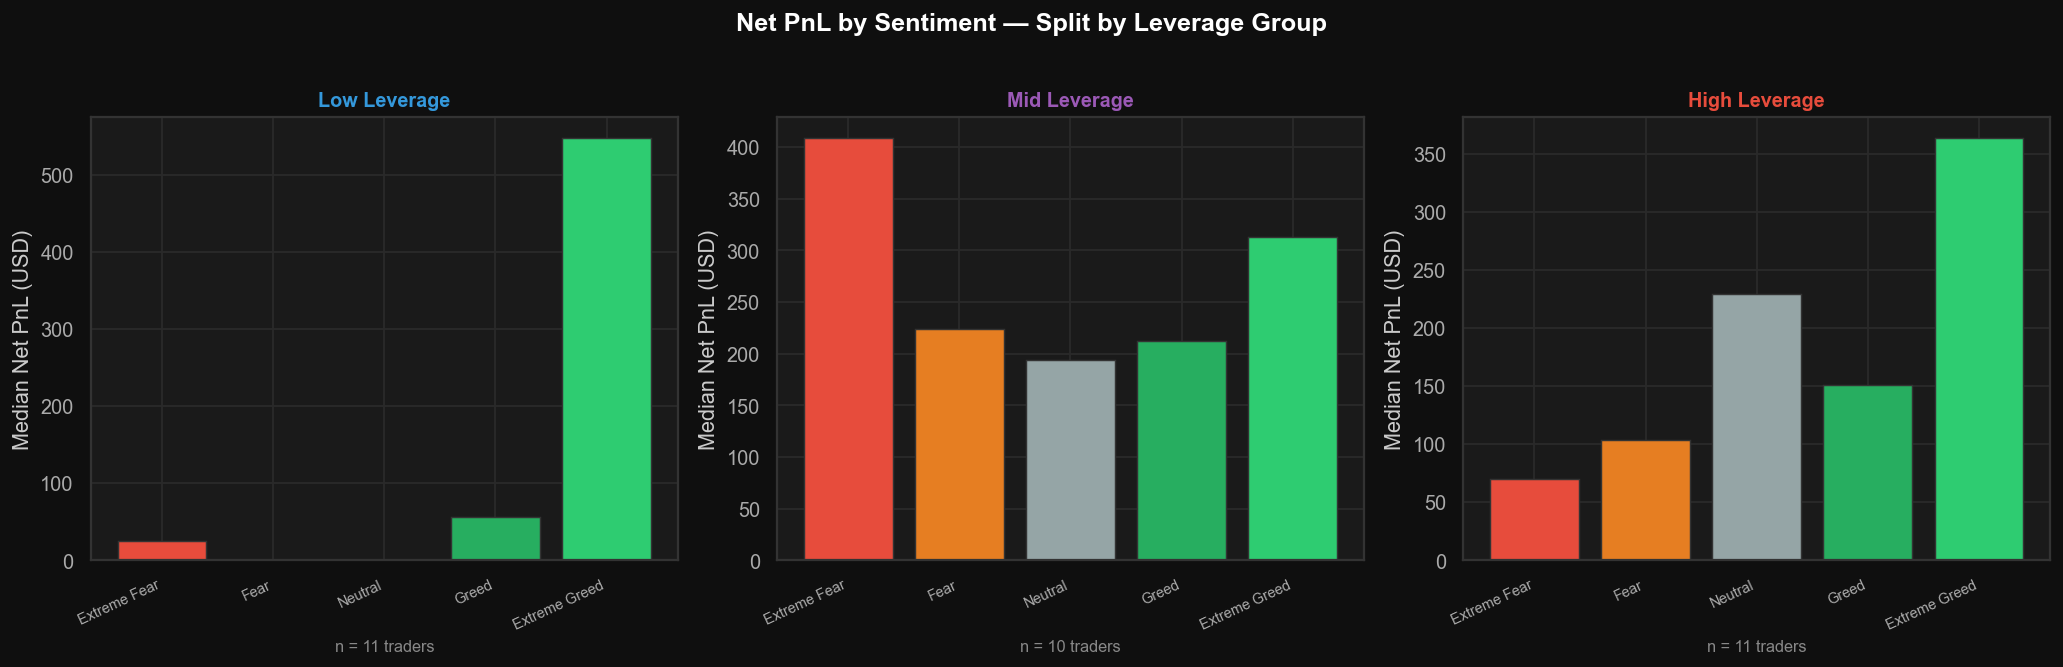

Saved → b9_pnl_sentiment_x_leverage.png


In [47]:
LEV_GROUPS  = ['Low Leverage', 'Mid Leverage', 'High Leverage']
LEV_COLORS  = ['#3498db', '#9b59b6', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Net PnL by Sentiment — Split by Leverage Group',
             fontsize=14, fontweight='bold', color='white', y=1.02)

for ax, group, color in zip(axes, LEV_GROUPS, LEV_COLORS):
    subset = daily_seg[daily_seg['leverage_group'] == group]
    pnl_grp = (
        subset.groupby('fg_label', observed=True)['net_pnl']
        .median()
        .reindex(SENTIMENT_ORDER)
    )
    bar_colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
    bars = ax.bar(SENTIMENT_ORDER, pnl_grp.values,
                  color=bar_colors, edgecolor='#333', linewidth=0.8)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{group}', fontsize=11, color=color, fontweight='bold')
    ax.set_ylabel('Median Net PnL (USD)')
    ax.set_xticklabels(SENTIMENT_ORDER, rotation=25, ha='right', fontsize=8)
    n = len(subset['Account'].unique())
    ax.set_xlabel(f'n = {n} traders', fontsize=9, color='#888')

plt.tight_layout()
plt.savefig('PrimeTrade AI/b9_pnl_sentiment_x_leverage.png', bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print("Saved → b9_pnl_sentiment_x_leverage.png")

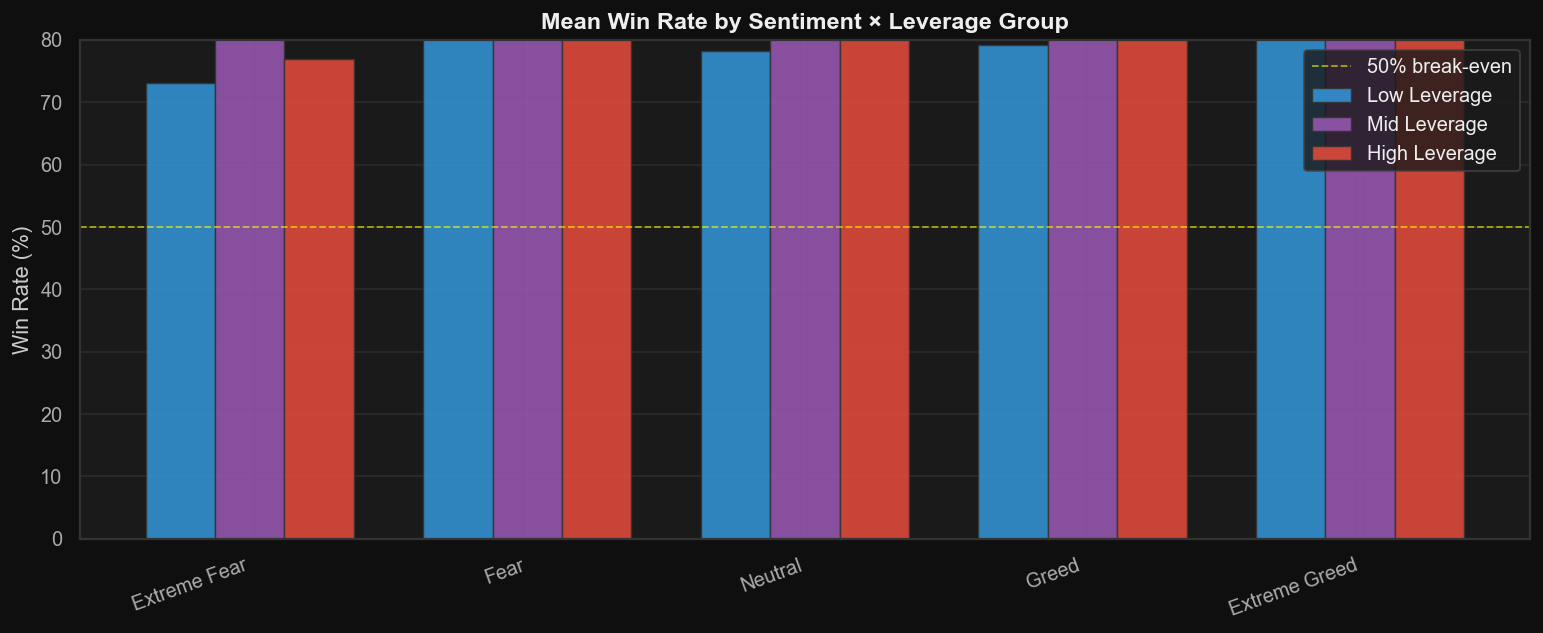

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

x       = np.arange(len(SENTIMENT_ORDER))
width   = 0.25
offsets = [-width, 0, width]

for offset, group, color in zip(offsets, LEV_GROUPS, LEV_COLORS):
    subset = daily_seg[daily_seg['leverage_group'] == group]
    wr_grp = (
        subset.groupby('fg_label', observed=True)['win_rate']
        .mean()
        .reindex(SENTIMENT_ORDER)
    ) * 100
    ax.bar(x + offset, wr_grp.values, width=width,
           label=group, color=color, edgecolor='#333', linewidth=0.8, alpha=0.85)

ax.axhline(50, color='yellow', linewidth=1, linestyle='--', alpha=0.6, label='50% break-even')
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax.set_title('Mean Win Rate by Sentiment × Leverage Group',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 80)
ax.legend()

plt.tight_layout()
plt.show()

Top traders    : 10 accounts
Bottom traders : 10 accounts


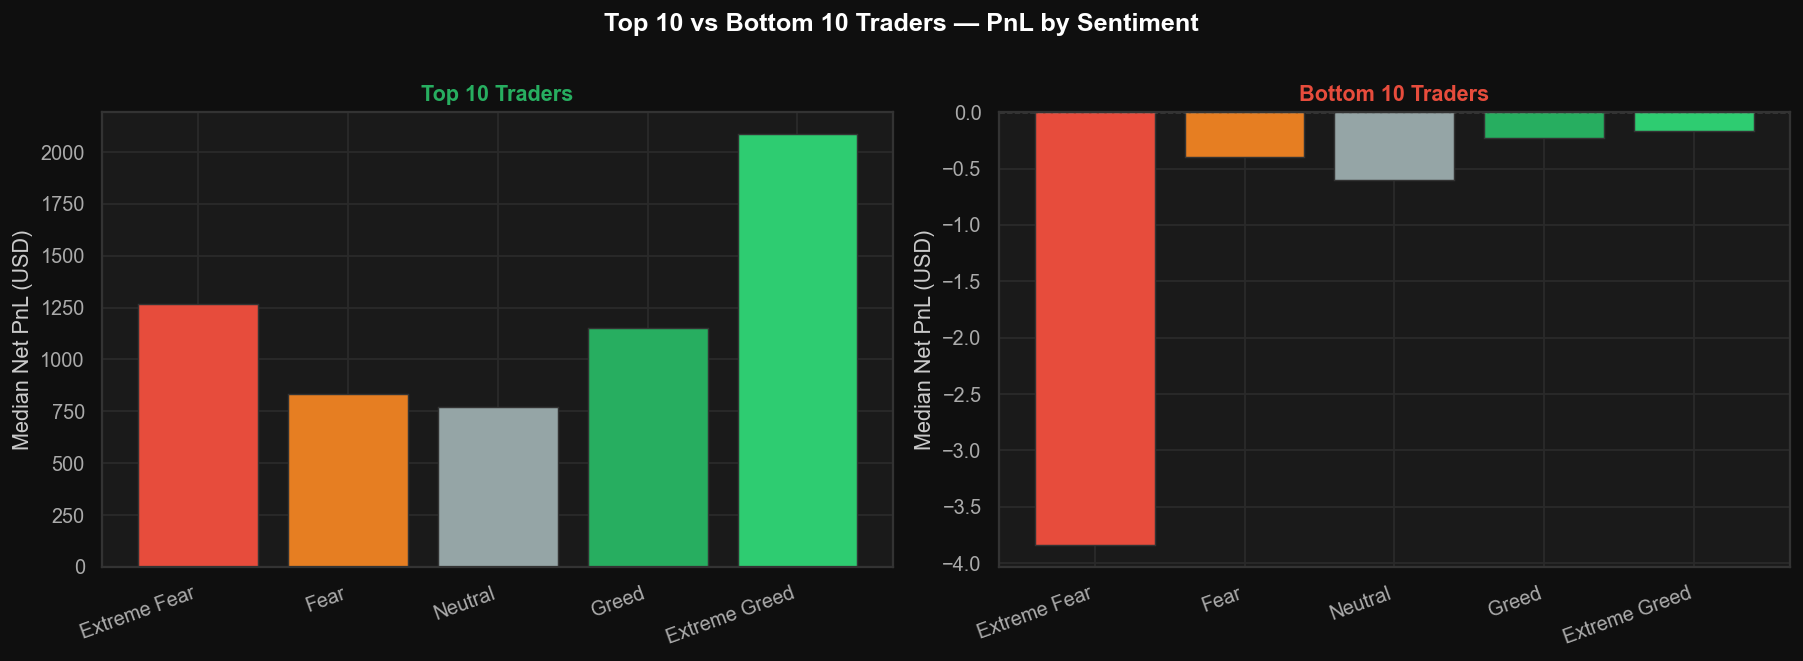

In [49]:
# Rank traders by their overall median net_pnl
trader_pnl_rank = (
    daily.groupby('Account')['net_pnl']
    .median()
    .sort_values(ascending=False)
)

n_cut = max(10, int(len(trader_pnl_rank) * 0.15))  # top/bottom 15% or at least 10
top_traders    = trader_pnl_rank.head(n_cut).index.tolist()
bottom_traders = trader_pnl_rank.tail(n_cut).index.tolist()

print(f"Top traders    : {len(top_traders)} accounts")
print(f"Bottom traders : {len(bottom_traders)} accounts")

top_daily    = daily[daily['Account'].isin(top_traders)]
bottom_daily = daily[daily['Account'].isin(bottom_traders)]

top_pnl_sent    = top_daily.groupby('fg_label', observed=True)['net_pnl'].median().reindex(SENTIMENT_ORDER)
bottom_pnl_sent = bottom_daily.groupby('fg_label', observed=True)['net_pnl'].median().reindex(SENTIMENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Top {n_cut} vs Bottom {n_cut} Traders — PnL by Sentiment',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, pnl_data, title, color in [
    (axes[0], top_pnl_sent,    f'Top {n_cut} Traders',    '#27ae60'),
    (axes[1], bottom_pnl_sent, f'Bottom {n_cut} Traders', '#e74c3c'),
]:
    ax.bar(SENTIMENT_ORDER, pnl_data.values,
           color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
           edgecolor='#333', linewidth=0.8)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=12, color=color, fontweight='bold')
    ax.set_ylabel('Median Net PnL (USD)')
    ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [50]:
top_pnl_sent, bottom_pnl_sent

(fg_label
 Extreme Fear     1266.939765
 Fear              832.921265
 Neutral           768.885198
 Greed            1149.824577
 Extreme Greed    2087.782833
 Name: net_pnl, dtype: float64,
 fg_label
 Extreme Fear    -3.839931
 Fear            -0.400000
 Neutral         -0.605851
 Greed           -0.228590
 Extreme Greed   -0.165790
 Name: net_pnl, dtype: float64)

### 7. Statistical Insights & Strategies

### 8. Simple predictive model

In [51]:
daily_seg = daily_seg.sort_values(["Account", "date"]).reset_index(drop=True)

In [52]:
daily_seg.sample(2)

,Account,date,fg_label,fg_value,trade_count,total_pnl,total_fee,net_pnl,win_rate,avg_size_usd,total_volume_usd,avg_leverage_proxy,long_short_ratio,leverage_group
828,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2024-10-13,Neutral,50.0,10,0.0,21.000841,-21.000841,NaN,6000.242000,60002.42,32651.802200,NaN,High Leverage
813,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2024-09-25,Greed,59.0,6,0.0,17.500388,-17.500388,NaN,8333.518333,50001.11,24282.551153,NaN,High Leverage


In [53]:
# ── Encode sentiment label ───────────────────────────────
sentiment_map = {
    "Extreme Fear": 1,
    "Fear":         2,
    "Neutral":      3,
    "Greed":        4,
    "Extreme Greed":5
}
daily_seg["fg_encoded"] = daily_seg["fg_label"].map(sentiment_map)

# ── Encode leverage group ────────────────────────────────
le = LabelEncoder()
daily_seg["leverage_group_enc"] = le.fit_transform(
    daily_seg["leverage_group"].astype(str)
)

# ── Final feature list ───────────────────────────────────
FEATURES = [
    "fg_encoded",
    "fg_value",
    "trade_count",
    "avg_leverage_proxy",
    "long_short_ratio",
    "avg_size_usd",
    "total_volume_usd",
    "leverage_group_enc"
]

In [54]:
# ── Target ───────────────────────────────────────────────
daily_seg["target_sameday"] = (daily_seg["net_pnl"] > 0).astype(int)
# 1 = profitable today, 0 = not profitable today

# ── Build model df ───────────────────────────────────────
model_df = daily_seg[FEATURES + ["target_sameday", "date"]].dropna()

train_df = model_df[FEATURES]
target_df = model_df["target_sameday"]

# ── Time Series Cross Validation ─────────────────────────
# IMPORTANT: never use random split for time series
# It would leak future data into training
tscv = TimeSeriesSplit(n_splits=4)

# ── Model ────────────────────────────────────────────────
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(
                    n_estimators=200,
                    max_depth=6,
                    class_weight="balanced",  # handles imbalanced win/loss
                    random_state=42
                ))
])

In [55]:
# ── Evaluate ─────────────────────────────────────────────
print("=== MODEL 1: Same-Day Profitability ===\n")
auc_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(train_df)):
    X_train, X_test = train_df.iloc[train_idx], train_df.iloc[test_idx]
    y_train, y_test = target_df.iloc[train_idx], target_df.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f"Fold {fold+1} AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

print(f"\nMean AUC across folds: {np.mean(auc_scores):.4f}")

=== MODEL 1: Same-Day Profitability ===

Fold 1 AUC: 0.6813
              precision    recall  f1-score   support

           0       0.50      0.05      0.09        21
           1       0.87      0.99      0.93       133

    accuracy                           0.86       154
   macro avg       0.68      0.52      0.51       154
weighted avg       0.82      0.86      0.81       154

Fold 2 AUC: 0.7809
              precision    recall  f1-score   support

           0       0.31      0.26      0.29        19
           1       0.90      0.92      0.91       135

    accuracy                           0.84       154
   macro avg       0.61      0.59      0.60       154
weighted avg       0.83      0.84      0.83       154

Fold 3 AUC: 0.4077
              precision    recall  f1-score   support

           0       0.09      0.11      0.10        27
           1       0.80      0.77      0.79       127

    accuracy                           0.66       154
   macro avg       0.45      0

In [56]:
def plot_feature_importance(model, feature_names, title):
    clf = model.named_steps["clf"]
    importances = clf.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    fi.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

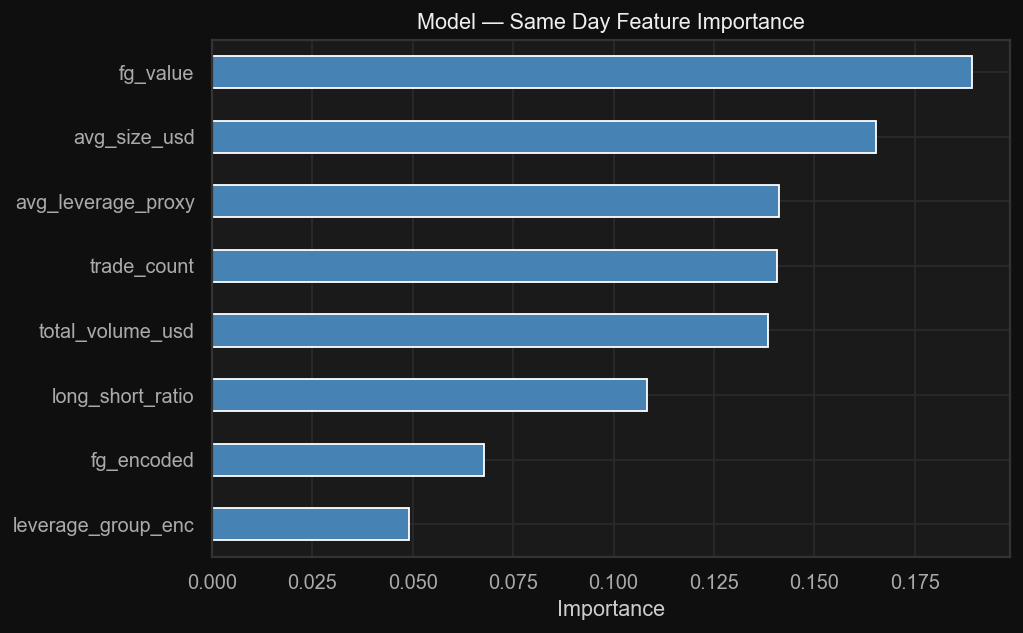

In [57]:
model.fit(train_df, target_df)
plot_feature_importance(model, FEATURES, "Model — Same Day Feature Importance")

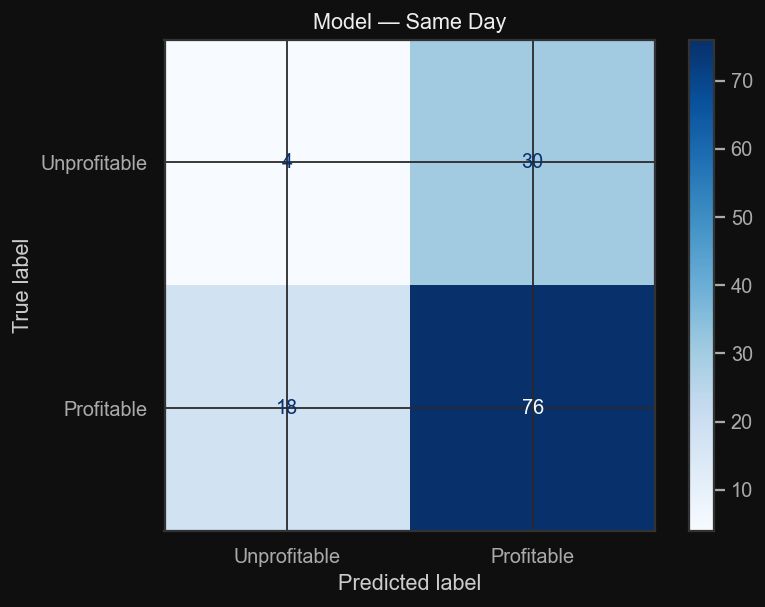

In [58]:
def plot_confusion(model, X, y, title):
    # Use last fold as representative test set
    split = TimeSeriesSplit(n_splits=5)
    *_, (train_idx, test_idx) = split.split(X)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred = model.predict(X.iloc[test_idx])

    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y.iloc[test_idx], y_pred,
        display_labels=["Unprofitable", "Profitable"],
        ax=ax, cmap="Blues"
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(model, train_df, target_df, "Model — Same Day")